<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from sklearn.linear_model import Ridge,Lasso
import matplotlib.pyplot as plt

In [3]:
np.random.seed(0)
X=np.random.randn(100,5)
y=X[:,0]*3+0.5*np.random.rand(100)

#ridge
ridge=Ridge(alpha=1.0)
ridge.fit(X,y)

#lasso
lasso=Lasso(alpha=0.1)
lasso.fit(X,y)

print("ridge regression",ridge.coef_)
print("lasso regression",lasso.coef_)

ridge regression [ 2.96890401e+00  1.46218558e-03  1.94344442e-02 -1.14224312e-02
  1.88540387e-02]
lasso regression [ 2.8953018 -0.         0.        -0.         0.       ]


In [4]:
#Comparing performance with and without regularization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
X=np.random.rand(20,1)
y=4+3*X+0.5*np.random.randn(20,1)

#Add an outlier to see how the model handle's the data.

X=np.append(X,[[1.8]],axis=0)
y=np.append(y,[[15.0]],axis=0)

#Standardize features to improve convergence.

X_scaled=(X-np.mean(X))/np.std(X)
X_b=np.c_[np.ones((len(X),1)),X_scaled]

def train_linear_regression(X_b,y,lr=0.1,iterations=100,lambda_reg=0):
  m=len(y)
  theta=np.random.randn(2,1)

  for i in range(iterations):
    errors=X_b.dot(theta)-y
    mse_grad=(2/m)*X_b.T.dot(errors)

    #L2 regularization.

    reg_grad=(2*lambda_reg/m)*theta

    reg_grad[0]=0
    gradients=mse_grad+reg_grad
    theta=theta-lr*gradients
  return theta



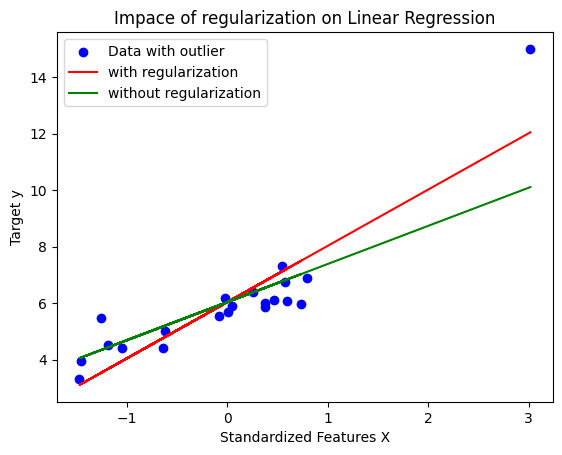

In [8]:
theta_no_reg=train_linear_regression(X_b,y,0.1,100,0)
theta_reg=train_linear_regression(X_b,y,0.1,100,10)

plt.plot(figsize=(10,6))
plt.scatter(X_scaled,y,color='blue',label="Data with outlier")
plt.plot(X_scaled,X_b.dot(theta_no_reg),color='red',label="with regularization")
plt.plot(X_scaled,X_b.dot(theta_reg),color='green',label="without regularization")
plt.xlabel("Standardized Features X")
plt.ylabel("Target y")
plt.title("Impace of regularization on Linear Regression")
plt.legend()
plt.show()
